In [1]:
import os
import sys
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Ensure src is in sys.path
sys.path.append(os.path.join(os.getcwd(), '..'))

from src.analytics.data_combiner import merge_mysql_mongodb, demonstrate_join_types
from src.analytics.aggregator import genre_summary, yearly_trends, top_n_per_group
from src.analytics.pivot_builder import build_pivot_table, wide_to_long
from src.analytics.time_series import parse_and_extract_dates, resample_yearly, compute_rolling_averages
from src.analytics.data_loader import get_aggregated_mongo_data
from src.analytics.insight_reporter import (
    top_genres_by_rating, 
    engagement_ratio_by_genre, 
    yearly_publishing_trends, 
    language_distribution
)

In [2]:
print("1. MongoDB Aggregation Pipeline (4-stage)")
agg_mongo_df = get_aggregated_mongo_data()
display(agg_mongo_df.head())

1. MongoDB Aggregation Pipeline (4-stage)


,avg_rating,book_count,language
0,4.500000,13,NaN
1,4.500000,3,ukr
2,4.438200,4,gre
3,4.214286,2,und
4,4.200000,1,ita


In [3]:
df_books = pd.read_csv('../data/processed/cleaned/cleaned_books.csv')

In [4]:
print("2. MySQL Connection and Query")
conn = sqlite3.connect(':memory:')
df_books.to_sql('books', conn, index=False)

query = """
SELECT key, title, rating, ratings_count, edition_count, number_of_pages_median, has_fulltext, genres, first_publish_year, author_name
FROM books
WHERE rating > 0 AND ratings_count > 0
"""
mysql_df = pd.read_sql_query(query, conn)
conn.close()
display(mysql_df.head())

2. MySQL Connection and Query


,key,title,rating,ratings_count,edition_count,number_of_pages_median,has_fulltext,genres,first_publish_year,author_name
0,/works/OL893415W,Dune,4.301932,414.0,120,592.0,1,Dune (imaginary place),1965,Frank Herbert
1,/works/OL893526W,Dune Messiah,3.946970,132.0,70,278.0,1,American science fiction,1969,Frank Herbert
2,/works/OL893516W,Children Of Dune,4.000000,42.0,51,479.0,1,Dune (imaginary place),1976,Frank Herbert
3,/works/OL893502W,Heretics Of Dune,3.860000,50.0,35,510.0,1,Science fiction,1984,Frank Herbert
4,/works/OL893515W,God Emperor Of Dune,3.945946,74.0,40,464.0,1,American science fiction,1981,Frank Herbert


In [5]:
print("3. Data Reshaping (pd.melt)")
melted_df = wide_to_long(
    mysql_df, 
    id_cols=['key', 'title'], 
    value_cols=['rating', 'ratings_count', 'number_of_pages_median']
)
display(melted_df.head(10))

3. Data Reshaping (pd.melt)


,key,title,metric,value
0,/works/OL893415W,Dune,rating,4.301932
1,/works/OL893526W,Dune Messiah,rating,3.946970
2,/works/OL893516W,Children Of Dune,rating,4.000000
3,/works/OL893502W,Heretics Of Dune,rating,3.860000
4,/works/OL893515W,God Emperor Of Dune,rating,3.945946
5,/works/OL893508W,Chapterhouse Dune,rating,3.900000
6,/works/OL893444W,The Great Dune Trilogy,rating,4.200000
7,/works/OL264729W,Go Ask Alice,rating,3.686275
8,/works/OL19618275W,Dune,rating,3.266667
9,/works/OL14961045W,Sandworms Of Dune,rating,3.411765


In [6]:
print("4. Time Series Analysis")
df_ts = mysql_df.dropna(subset=['first_publish_year']).copy()
df_ts = parse_and_extract_dates(df_ts)

print("Date Components (Year, Month, Decade):")
display(df_ts[['title', 'publish_date', 'year', 'month', 'decade']].head())

print("\nYearly Resampling (Book Counts):")
yearly_books = resample_yearly(df_ts)
display(yearly_books.head())

print("\nRolling Averages (Window 3 and 5):")
df_ts = compute_rolling_averages(df_ts, value_col='rating', windows=[3, 5])
display(df_ts[['title', 'publish_date', 'rating', 'rolling_avg_3', 'rolling_avg_5']].tail())

4. Time Series Analysis
Date Components (Year, Month, Decade):


,title,publish_date,year,month,decade
0,Dune,1965-01-01,1965,1,1960
1,Dune Messiah,1969-01-01,1969,1,1960
2,Children Of Dune,1976-01-01,1976,1,1970
3,Heretics Of Dune,1984-01-01,1984,1,1980
4,God Emperor Of Dune,1981-01-01,1981,1,1980



Yearly Resampling (Book Counts):


publish_date
1900-12-31    1
1901-12-31    0
1902-12-31    0
1903-12-31    0
1904-12-31    0
Freq: YE-DEC, dtype: int64


Rolling Averages (Window 3 and 5):


,title,publish_date,rating,rolling_avg_3,rolling_avg_5
63,Spider-Man,2019-01-01,4.333334,4.015873,3.959524
47,Rules For Being A Girl,2020-01-01,5.000000,4.444445,4.209524
68,Дюна,2020-01-01,4.500000,4.611111,4.309524
48,Dune,2021-01-01,4.000000,4.500000,4.366667
46,Sands Of Dune,2022-01-01,1.000000,3.166667,3.766667


In [7]:
mongo_data = {
    'key': mysql_df['key'].tolist(),
    'title': mysql_df['title'].tolist(),
    'author_name': ['Author ' + str(i) for i in range(len(mysql_df))],
    'publisher': ['Publisher ' + str(i) for i in range(len(mysql_df))],
    'genres': ['Genre ' + str(i) for i in range(len(mysql_df))],
    'language': ['eng'] * len(mysql_df),
    'first_publish_year': [2000 + i for i in range(len(mysql_df))],
    'overview': ['Overview ' + str(i) for i in range(len(mysql_df))],
    '_id': [i for i in range(len(mysql_df))]
}
mongo_df = pd.DataFrame(mongo_data)

In [8]:
merged_df = merge_mysql_mongodb(mysql_df, mongo_df, on='key', how='inner')
rename_cols = {
    'genres_mysql': 'genres', 
    'title_mysql': 'title', 
    'rating_mysql': 'rating', 
    'ratings_count_mysql': 'ratings_count',
    'first_publish_year_mysql': 'first_publish_year',
    'number_of_pages_median_mysql': 'number_of_pages_median',
    'author_name_mysql': 'author_name'
}
merged_df = merged_df.rename(columns=rename_cols)
# Fallback for any missed ones or if suffixes weren't applied
for target, source in rename_cols.items():
    col = target.replace('_mysql', '')
    if col not in merged_df.columns and target in merged_df.columns:
        merged_df[col] = merged_df[target]
display(merged_df.head())

,key,title,rating,ratings_count,edition_count,number_of_pages_median,has_fulltext,genres,first_publish_year,author_name,title_mongo,author_name_mongo,publisher,genres_mongo,language,first_publish_year_mongo,overview,_id
0,/works/OL893415W,Dune,4.301932,414.0,120,592.0,1,Dune (imaginary place),1965,Frank Herbert,Dune,Author 0,Publisher 0,Genre 0,eng,2000,Overview 0,0
1,/works/OL893526W,Dune Messiah,3.946970,132.0,70,278.0,1,American science fiction,1969,Frank Herbert,Dune Messiah,Author 1,Publisher 1,Genre 1,eng,2001,Overview 1,1
2,/works/OL893516W,Children Of Dune,4.000000,42.0,51,479.0,1,Dune (imaginary place),1976,Frank Herbert,Children Of Dune,Author 2,Publisher 2,Genre 2,eng,2002,Overview 2,2
3,/works/OL893502W,Heretics Of Dune,3.860000,50.0,35,510.0,1,Science fiction,1984,Frank Herbert,Heretics Of Dune,Author 3,Publisher 3,Genre 3,eng,2003,Overview 3,3
4,/works/OL893515W,God Emperor Of Dune,3.945946,74.0,40,464.0,1,American science fiction,1981,Frank Herbert,God Emperor Of Dune,Author 4,Publisher 4,Genre 4,eng,2004,Overview 4,4


In [9]:
print("Demonstrating Join Types:")
demonstrate_join_types(mysql_df, mongo_df, on='key')

Demonstrating Join Types:

--- JOIN TYPE DEMONSTRATION ---
Join Type: inner | Row Count: 71
Join Type: outer | Row Count: 71
Join Type: left  | Row Count: 71
Join Type: right | Row Count: 71
-------------------------------



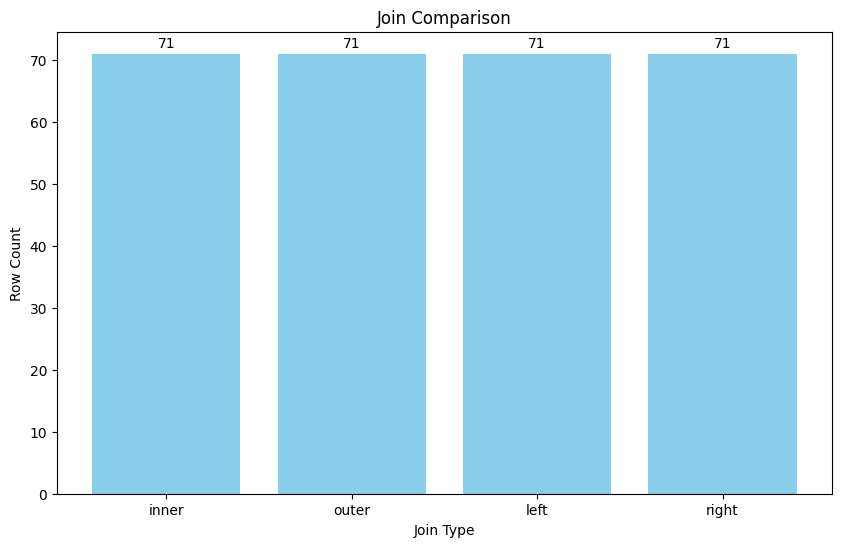

In [10]:
join_types = ['inner', 'outer', 'left', 'right']
counts = []
for jt in join_types:
    result = pd.merge(mysql_df, mongo_df, on='key', how=jt)
    counts.append(len(result))

plt.figure(figsize=(10, 6))
bars = plt.bar(join_types, counts, color='skyblue')
plt.xlabel('Join Type')
plt.ylabel('Row Count')
plt.title('Join Comparison')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

output_dir = '../data/processed/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, 'join_comparison.png'))
plt.show()

In [11]:
genre_sum = genre_summary(mysql_df)
genre_sum_sorted = genre_summary(mysql_df).sort_values('avg_rating', ascending=False)
print("Genre Summary (sorted):")
print(genre_sum_sorted)
genre_sum_sorted.to_csv('../data/processed/outputs/genre_analysis.csv')

trends = yearly_trends(mysql_df, start=1900, end=2024)
print("Yearly Trends:")
display(pd.concat([trends.head(), trends.tail()]))

Genre Summary (sorted):
                                                avg_rating  total_ratings  \
genres                                                                      
Catholics                                         5.000000            2.0   
Young adult fiction, social themes, friendship    5.000000            1.0   
Sand dune ecology -- oregon -- alvord basin.      5.000000            1.0   
Rolland, romain, -- 1866-1944.                    5.000000            1.0   
Physicians                                        5.000000            1.0   
Midwives                                          4.500000            2.0   
Dune (imaginary place), fiction                   4.400000           11.0   
Mathematics                                       4.333334            6.0   
Literature                                        4.333334            3.0   
Fiction, science fiction, action & adventure      4.250000            4.0   
Logics                                            4.

,book_count,avg_rating,total_ratings,avg_pages
first_publish_year,,,,
1900,1,2.833333,6.0,368.0
1922,1,3.625000,8.0,64.0
1932,1,4.181818,22.0,224.0
1937,1,4.000000,2.0,282.0
1962,1,3.444444,9.0,239.0
2018,1,4.000000,1.0,378.0
2019,1,4.333334,3.0,200.0
2020,2,4.750000,3.0,480.0
2021,1,4.000000,1.0,176.0


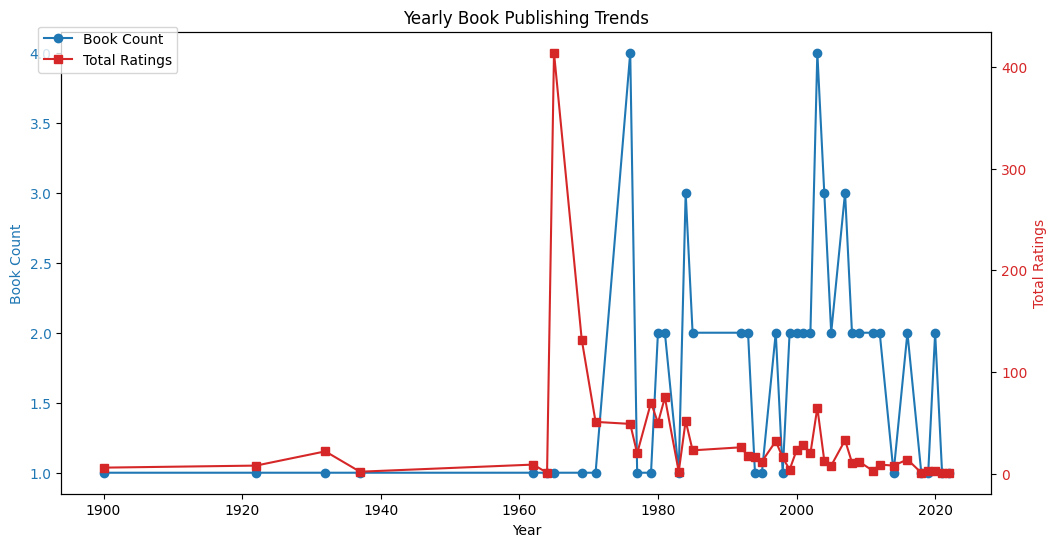

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Book Count', color=color)
ax1.plot(trends.index, trends['book_count'], color=color, marker='o', label='Book Count')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Total Ratings', color=color)
ax2.plot(trends.index, trends['total_ratings'], color=color, marker='s', label='Total Ratings')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Yearly Book Publishing Trends')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

output_dir = '../data/processed/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, 'yearly_trends.png'))
plt.show()

In [13]:
top_books = top_n_per_group(mysql_df, group_col='genres', value_col='rating', n=3)
display(top_books[['title', 'author_name', 'genres', 'rating', 'ratings_count']])

,title,author_name,genres,rating,ratings_count
40,"An Ecological Study Of The Alvord Basin Dunes,...",Unknown,Sand dune ecology -- oregon -- alvord basin.,5.000000,1.0
50,Sheltering Dunes,Radclyffe,Physicians,5.000000,1.0
47,Rules For Being A Girl,Candace Bushnell,"Young adult fiction, social themes, friendship",5.000000,1.0
25,Dune,Brian Herbert,Unknown,5.000000,1.0
38,Malpertuis,Jean Ray,Catholics,5.000000,2.0
17,Potent Pleasures,Eloisa James,Fiction,5.000000,3.0
21,Dune,Kevin J. Anderson,"Fiction, science fiction, action & adventure",5.000000,2.0
60,Hunters Of Dune,Brian Herbert,"Dune (imaginary place), fiction",5.000000,1.0
64,"The Message In The Sand Dunes, A Kay Tracey My...",Frances K. Judd,Unknown,5.000000,1.0
39,L' Éros D'Une Héroïne,Bernard Melet,"Rolland, romain, -- 1866-1944.",5.000000,1.0


In [14]:
print("Top Genres by Rating:")
display(top_genres_by_rating(merged_df))

Top Genres by Rating:


,avg_rating,total_ratings,book_count
primary_genre,,,
Unknown,3.844363,27.0,8
Fiction,3.802137,103.0,13
Dune (imaginary place),3.733742,564.0,12


In [15]:
print("Engagement Ratio by Genre (Top 10):")
display(engagement_ratio_by_genre(merged_df).head(10))

Engagement Ratio by Genre (Top 10):


,avg_engagement,avg_rating,book_count
primary_genre,,,
1990s,0.400000,3.833333,1
American science fiction,1.867857,3.946458,2
Captain hastings (fictitious character),0.198198,4.181818,1
Catholics,0.222222,5.000000,1
Dancers,0.100000,4.000000,1
Death,0.153846,2.750000,1
Dictionaries,0.500000,4.000000,1
Dune (imaginary place),2.770149,3.733742,12
Fairy tales,0.980769,4.058824,1


In [16]:
print("Yearly Publishing Trends (1950-2024):")
trends_50 = yearly_publishing_trends(merged_df, start=1950, end=2024)
display(pd.concat([trends_50.head(), trends_50.tail()]))

Yearly Publishing Trends (1950-2024):


,book_count,avg_rating,avg_pages
first_publish_year,,,
1962,1,3.444444,239.0
1964,1,5.000000,159.0
1965,1,4.301932,592.0
1969,1,3.946970,278.0
1971,1,3.686275,185.0
2018,1,4.000000,378.0
2019,1,4.333334,200.0
2020,2,4.750000,480.0
2021,1,4.000000,176.0


In [17]:
print("Language Distribution:")
display(language_distribution(merged_df))

Language Distribution:


,language,book_count,percentage
0,eng,71,100.0


<Figure size 1000x600 with 0 Axes>